## Experiment 2: Data Quality Check And Cleaning


In [1]:
# Import required libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from io import StringIO
import warnings
from scipy.optimize import curve_fit

In [2]:
# Nature-style plotting configuration
import sys
from pathlib import Path
for _shared_path in (Path('shared'), Path('notebooks/shared')):
    if _shared_path.exists():
        sys.path.insert(0, str(_shared_path))

import matplotlib.pyplot as plt
import seaborn as sns
from plot_config import (
    set_nature_style, COLORS, TRANSITION_ORDER, TRANSITION_PALETTE,
    DURATION_ORDER, get_transition_palette, despine
)
set_nature_style()

#### Load raw data

In [19]:
def basic_cleaning(data_folder):
    all_dfs = []
    files = glob.glob(os.path.join(data_folder, '*.csv'))
    print(f" Found {len(files)} CSV files in {data_folder}")
    encodings_to_try = ['utf-8', 'utf-8-sig', 'latin1', 'gbk', 'windows-1252']
    for file_path in files:
        lines = None
        for enc in encodings_to_try:
            try:
                with open(file_path, 'r', encoding=enc) as f:
                    lines = f.readlines()
                break  
            except UnicodeDecodeError:
                continue
        if lines is None:
            continue
        if len(lines) < 4:
            print(f" File too short: {file_path}")
            continue
        cleaned_lines = [lines[0]] + lines[33:]
        try:
            df_temp = pd.read_csv(StringIO(''.join(cleaned_lines)))
        except Exception as e:
            continue
        if 'keyDuration' not in df_temp.columns or 'TimeDur' not in df_temp.columns:
            continue
        try:
            df_temp['keyDuration'] = df_temp['keyDuration'] / 1000.0
            df_temp['ReproductionError'] = df_temp['keyDuration'] - df_temp['TimeDur']
            sub_id = os.path.basename(file_path).split('_')[0]
            df_temp['subID'] = sub_id
            all_dfs.append(df_temp)
        except Exception as e:
            continue
    if not all_dfs:
        return pd.DataFrame()
    print(f" Successfully processed {len(all_dfs)} files")
    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

def clean_extremes_grouped_by_duration(
    df_all,
    error_thresh=0.6,
    time_bounds=(0.8, 1.6),
    verbose=True
):
    """
    ： TimeDur  IQR ， is_outlier 。
    ：
        df_all (pd.DataFrame):  'TimeDur', 'keyDuration', 'ReproductionError'  DataFrame
        error_thresh (float): 
        time_bounds (tuple):  TimeDur 
        verbose (bool):  trial 
    ：
        pd.DataFrame:  'is_outlier'  DataFrame
    """
    df_all = df_all.copy().assign(is_outlier=False)
    for dur, df_group in df_all.groupby("TimeDur"):
        if not (time_bounds[0] <= dur <= time_bounds[1]):
            df_all.loc[df_group.index, "is_outlier"] = True
            continue
        if df_group["keyDuration"].isna().all() or df_group["ReproductionError"].isna().all():
            continue
        q1 = df_group["keyDuration"].quantile(0.25)
        q3 = df_group["keyDuration"].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask_iqr = (df_group["keyDuration"] < lower) | (df_group["keyDuration"] > upper)
        mask_err = df_group["ReproductionError"].abs() > error_thresh
        final_mask = mask_iqr | mask_err
        df_all.loc[df_group[final_mask].index, "is_outlier"] = True
    if verbose:
        n_outliers = df_all["is_outlier"].sum()
        print(f"Marked {n_outliers} outliers")
    return df_all

def construct_trial_variables(df, max_n_back=10, max_n_future=2, verbose=True):  
    df = df.copy()
    # Rename columns to standard names
    df = df.rename(columns={
        'trials.thisN': 'trial_num',
        'TimeDur': 'curDur',
        'keyDuration': 'rpr',
        'ReproductionError': 'curBias',
        'Coherence1': 'curCoherence'
    })
    # ========== Create past (n-back) variables ==========
    df['preDur1back'] = df.groupby('subID')['curDur'].shift(1)
    df['preCoherence1back'] = df.groupby('subID')['curCoherence'].shift(1)
    for n in range(2, max_n_back + 1):
        df[f'preDur{n}back'] = df.groupby('subID')['curDur'].shift(n)
        df[f'preCoherence{n}back'] = df.groupby('subID')['curCoherence'].shift(n)
    # ========== Create future (n+f) variables ==========
    for f in range(1, max_n_future + 1):
        df[f'postDur{f}'] = df.groupby('subID')['curDur'].shift(-f)
        df[f'postCoherence{f}'] = df.groupby('subID')['curCoherence'].shift(-f)
    # ========== TransitionType ==========
    def classify_transition(row):
        if pd.isnull(row['preCoherence1back']):
            return np.nan
        prev = 'Low' if row['preCoherence1back'] == 0.7 else 'High'
        curr = 'Low' if row['curCoherence'] == 0.7 else 'High'
        return prev[0] + curr[0]
    df['TransitionType'] = df.apply(classify_transition, axis=1)
    if 'is_outlier' not in df.columns:
        df['is_outlier'] = False
    df.loc[(df['trial_num'] - 1) % 30 == 0, 'is_outlier'] = True
    df.loc[df['trial_num'] == 30, 'is_outlier'] = True
    # ========== Build list of all relevant columns ==========
    core_cols = ['subID', 'trial_num', 'curDur', 'rpr', 'curBias', 'curCoherence',
                 'preDur1back', 'preCoherence1back', 'TransitionType', 'is_outlier']
    pre_cols = [f'preDur{n}back' for n in range(2, max_n_back + 1)] + \
               [f'preCoherence{n}back' for n in range(2, max_n_back + 1)]
    post_cols = [f'postDur{f}' for f in range(1, max_n_future + 1)] + \
                [f'postCoherence{f}' for f in range(1, max_n_future + 1)]
    keep_cols = core_cols + pre_cols + post_cols
    keep_cols = [col for col in keep_cols if col in df.columns]
    if verbose:
        print(f"Constructed {len(keep_cols)} columns for {df['subID'].nunique()} subjects")
    return df[keep_cols].copy()

df = basic_cleaning('../rawdata')
df = clean_extremes_grouped_by_duration(df)
df = construct_trial_variables(df)
print(f"Loaded {len(df)} rows, {df['subID'].nunique()} subjects")
print(f"Subjects: {sorted(df['subID'].unique())}")
%config InlineBackend.figure_format = 'retina'

 Found 68 CSV files in ../rawdata
 Successfully processed 68 files
Marked 9238 outliers
Constructed 32 columns for 68 subjects
Loaded 16321 rows, 68 subjects
Subjects: ['026578', '035679', '045991', '064995', '101109', '109550', '132230', '158214', '171761', '199724', '199905', '213720', '215827', '228809', '241220', '243787', '312070', '328537', '349889', '351076', '355759', '383828', '384894', '402658', '405532', '409', '421766', '457570', '459907', '513989', '573583', '580953', '614807', '615008', '624989', '649241', '653663', '657789', '658375', '660485', '671778', '681174', '722448', '730111', '738855', '743968', '768696', '781145', '784269', '785063', '785667', '787955', '803870', '820531', '826373', '828098', '85216115', '866424', '882052', '897347', '919598', '920169', '933331', '937984', '963221', '996804', 'czr', 'txy']


#### Extract Prolific IDs (for online experiments)

In [4]:
# Function 0: extract prolific IDs
def extract_all_prolific_pids(data_folder):
    pid_dict = {}
    for file_path in glob.glob(os.path.join(data_folder, '*.csv')):
        sub_id = os.path.basename(file_path).split('_')[0]
        try:
            df = pd.read_csv(file_path)
            if 'PROLIFIC_PID' in df.columns:
                pid = df['PROLIFIC_PID'].iloc[0]
                pid_dict[sub_id] = pid
            else:
                pid_dict[sub_id] = 'NOT FOUND'
        except Exception as e:
            pid_dict[sub_id] = f'ERROR: {e}'
    return pid_dict
    Usage
    prolific_ids = extract_all_prolific_pids("path/to/data/folder")
    prolific_ids = extract_all_prolific_pids("path/to/data/folder")
    df_summary['PROLIFIC_PID'] = df_summary['subID'].map(prolific_ids)

#### Load raw data

#### Load and clean raw data
Remove first 33 rows (30 practice trials + 3 screen setup rows).

In [5]:
import os
import glob
import pandas as pd
from io import StringIO

def basic_cleaning(data_folder):
    all_dfs = []
    files = glob.glob(os.path.join(data_folder, '*.csv'))
    print(f" Found {len(files)} CSV files in {data_folder}")
    encodings_to_try = ['utf-8', 'utf-8-sig', 'latin1', 'gbk', 'windows-1252']
    for file_path in files:
        lines = None
        for enc in encodings_to_try:
            try:
                with open(file_path, 'r', encoding=enc) as f:
                    lines = f.readlines()
                break  
            except UnicodeDecodeError:
                continue
        if lines is None:
            continue
        if len(lines) < 4:
            print(f" File too short: {file_path}")
            continue
        cleaned_lines = [lines[0]] + lines[33:]
        try:
            df = pd.read_csv(StringIO(''.join(cleaned_lines)))
        except Exception as e:
            continue
        if 'keyDuration' not in df.columns or 'TimeDur' not in df.columns:
            continue
        try:
            df['keyDuration'] = df['keyDuration'] / 1000.0
            df['ReproductionError'] = df['keyDuration'] - df['TimeDur']
            sub_id = os.path.basename(file_path).split('_')[0]
            df['subID'] = sub_id
            all_dfs.append(df)
        except Exception as e:
            continue
    if not all_dfs:
        return pd.DataFrame()
    print(f" Successfully processed {len(all_dfs)} files")
    combined_df = pd.concat(all_dfs, ignore_index=True)
    return combined_df

In [6]:
# Data already loaded from Modeldata/E2.pkl above
# Skip raw data processing
print(f"Data loaded: {len(df)} rows, {df['subID'].nunique()} subjects")

Data loaded: 5280 rows, 22 subjects


#### Calculate trial retention ratio per subject

In [7]:
def calculate_trial_ratio(df, full_trial_count=240, use_outlier_column=True):
    """
     trial ：
        -  is_outlier 
        -  trial 、 trial 
    ：
        df (pd.DataFrame):  'subID'  'is_outlier'  dataframe
        full_trial_count (int or dict):  trial （， subID:count ）
        use_outlier_column (bool):  'is_outlier' 
    ：
        pd.DataFrame:  trial 
    """
    df = df.copy()
    if use_outlier_column and 'is_outlier' in df.columns:
        df_valid = df[df['is_outlier'] == False]
    else:
        df_valid = df
    total_trials = df.groupby('subID').size().rename('total_trials')
    valid_trials = df_valid.groupby('subID').size().rename('valid_trials')
    summary = pd.concat([total_trials, valid_trials], axis=1).fillna(0)
    summary['valid_trials'] = summary['valid_trials'].astype(int)
    if isinstance(full_trial_count, dict):
        summary['full_expected'] = summary.index.map(full_trial_count).fillna(240)
    else:
        summary['full_expected'] = full_trial_count
    summary['valid_ratio'] = summary['valid_trials'] / summary['full_expected']
    return summary.reset_index()


#### Outlier removal function
Remove outliers per `TimeDur` using IQR filtering + absolute error threshold.

In [8]:
def clean_extremes_grouped_by_duration(
    df_all,
    error_thresh=0.6,
    time_bounds=(0.8, 1.6),
    verbose=True
):
    """
    ： TimeDur  IQR ， is_outlier 。
    ：
        df_all (pd.DataFrame):  'TimeDur', 'keyDuration', 'ReproductionError'  DataFrame
        error_thresh (float): 
        time_bounds (tuple):  TimeDur 
        verbose (bool):  trial 
    ：
        pd.DataFrame:  'is_outlier'  DataFrame
    """
    df_all = df_all.copy().assign(is_outlier=False)
    for dur, df_group in df_all.groupby("TimeDur"):
        if not (time_bounds[0] <= dur <= time_bounds[1]):
            df_all.loc[df_group.index, "is_outlier"] = True
            continue
        if df_group["keyDuration"].isna().all() or df_group["ReproductionError"].isna().all():
            continue
        q1 = df_group["keyDuration"].quantile(0.25)
        q3 = df_group["keyDuration"].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask_iqr = (df_group["keyDuration"] < lower) | (df_group["keyDuration"] > upper)
        mask_err = df_group["ReproductionError"].abs() > error_thresh
        final_mask = mask_iqr | mask_err
        df_all.loc[df_group[final_mask].index, "is_outlier"] = True
    if verbose:
        n_outliers = df_all["is_outlier"].sum()
    return df_all


#### Outlier Removal Strategy
For each `TimeDur`, trials were excluded if: (1) `keyDuration` outside IQR ± 1.5×IQR, or (2) |ReproductionError| > 0.6s. Trials with `TimeDur` outside [0.8, 1.6]s were also discarded.

In [9]:
# Data already cleaned in Modeldata - show summary
print(f"Total rows: {len(df)}")
print(f"Outliers: {df['is_outlier'].sum()} / {len(df)}")
print(f"Subjects: {df['subID'].nunique()}")

Total rows: 5280
Outliers: 603 / 5280
Subjects: 22


#### Construct trial-level variables
Rename columns, compute n-back variables, and define `TransitionType` (HH, HL, LH, LL) based on coherence transitions.

In [10]:
def construct_trial_variables(df, max_n_back=10, max_n_future=2, verbose=True):  
    df = df.copy()
    # Rename columns to standard names
    df = df.rename(columns={
        'trials.thisN': 'trial_num',
        'TimeDur': 'curDur',
        'keyDuration': 'rpr',
        'ReproductionError': 'curBias',
        'Coherence1': 'curCoherence'
    })
    # ========== Create past (n-back) variables ==========
    df['preDur1back'] = df.groupby('subID')['curDur'].shift(1)
    df['preCoherence1back'] = df.groupby('subID')['curCoherence'].shift(1)
    for n in range(2, max_n_back + 1):
        df[f'preDur{n}back'] = df.groupby('subID')['curDur'].shift(n)
        df[f'preCoherence{n}back'] = df.groupby('subID')['curCoherence'].shift(n)
    # ========== Create future (n+f) variables ==========
    for f in range(1, max_n_future + 1):
        df[f'postDur{f}'] = df.groupby('subID')['curDur'].shift(-f)
        df[f'postCoherence{f}'] = df.groupby('subID')['curCoherence'].shift(-f)
    # ========== TransitionType ==========
    def classify_transition(row):
        if pd.isnull(row['preCoherence1back']):
            return np.nan
        prev = 'Low' if row['preCoherence1back'] == 0.7 else 'High'
        curr = 'Low' if row['curCoherence'] == 0.7 else 'High'
        return prev[0] + curr[0]
    df['TransitionType'] = df.apply(classify_transition, axis=1)
    if 'is_outlier' not in df.columns:
        df['is_outlier'] = False
    df.loc[(df['trial_num'] - 1) % 30 == 0, 'is_outlier'] = True
    df.loc[df['trial_num'] == 30, 'is_outlier'] = True
    # ========== Build list of all relevant columns ==========
    core_cols = ['subID', 'trial_num', 'curDur', 'rpr', 'curBias', 'curCoherence',
                 'preDur1back', 'preCoherence1back', 'TransitionType', 'is_outlier']
    pre_cols = [f'preDur{n}back' for n in range(2, max_n_back + 1)] + \
               [f'preCoherence{n}back' for n in range(2, max_n_back + 1)]
    post_cols = [f'postDur{f}' for f in range(1, max_n_future + 1)] + \
                [f'postCoherence{f}' for f in range(1, max_n_future + 1)]
    keep_cols = core_cols + pre_cols + post_cols
    keep_cols = [col for col in keep_cols if col in df.columns]
    if verbose:
        print(f"Constructed {len(keep_cols)} columns for {df['subID'].nunique()} subjects")
    return df[keep_cols].copy()

#### Filter participants by trial retention
Include only subjects with >80% valid trials.

In [11]:
# Data already filtered and variables constructed in Modeldata
print(f"Final dataset: {len(df)} rows, {df['subID'].nunique()} subjects")
print(f"Columns: {df.columns.tolist()}")

Final dataset: 5280 rows, 22 subjects
Columns: ['subID', 'trial_num', 'curDur', 'rpr', 'curBias', 'curCoherence', 'preDur1back', 'preCoherence1back', 'TransitionType', 'is_outlier', 'preDur2back', 'preDur3back', 'preDur4back', 'preDur5back', 'preDur6back', 'preDur7back', 'preDur8back', 'preDur9back', 'preDur10back', 'preCoherence2back', 'preCoherence3back', 'preCoherence4back', 'preCoherence5back', 'preCoherence6back', 'preCoherence7back', 'preCoherence8back', 'preCoherence9back', 'preCoherence10back', 'postDur1', 'postDur2', 'postCoherence1', 'postCoherence2', 'preDur1backc', 'curDurc', 'mean_rpr', 'resp_type', 'preResp']


#### Distribution checks
Histograms and Q-Q plots per subject.

In [12]:
#  Function  plotting histograms for each subject
def plot_histograms(df, column='keyDuration', groupby='subID', bins=30):
    subjects = df[groupby].unique()
    n_cols = 7
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column]
        axes[i].hist(sub_data.dropna(), bins=bins, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{column} Histogram - {sub}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
    # Remove unused subplots
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)
    plt.tight_layout()
    plt.show()
#  Function  plotting Q-Q plots for each subject
def plot_qqplots(df, column='keyDuration', groupby='subID'):
    subjects = df[groupby].unique()
    n_cols = 7
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column].dropna()
        stats.probplot(sub_data, dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot - {sub}')
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)
        plt.tight_layout()
    plt.show()


In [13]:
plot_histograms(df, column='rpr', groupby='subID')
plot_qqplots(df, column='rpr', groupby='subID')

#### Transition type distribution
Check balance of HH, HL, LH, LL conditions.

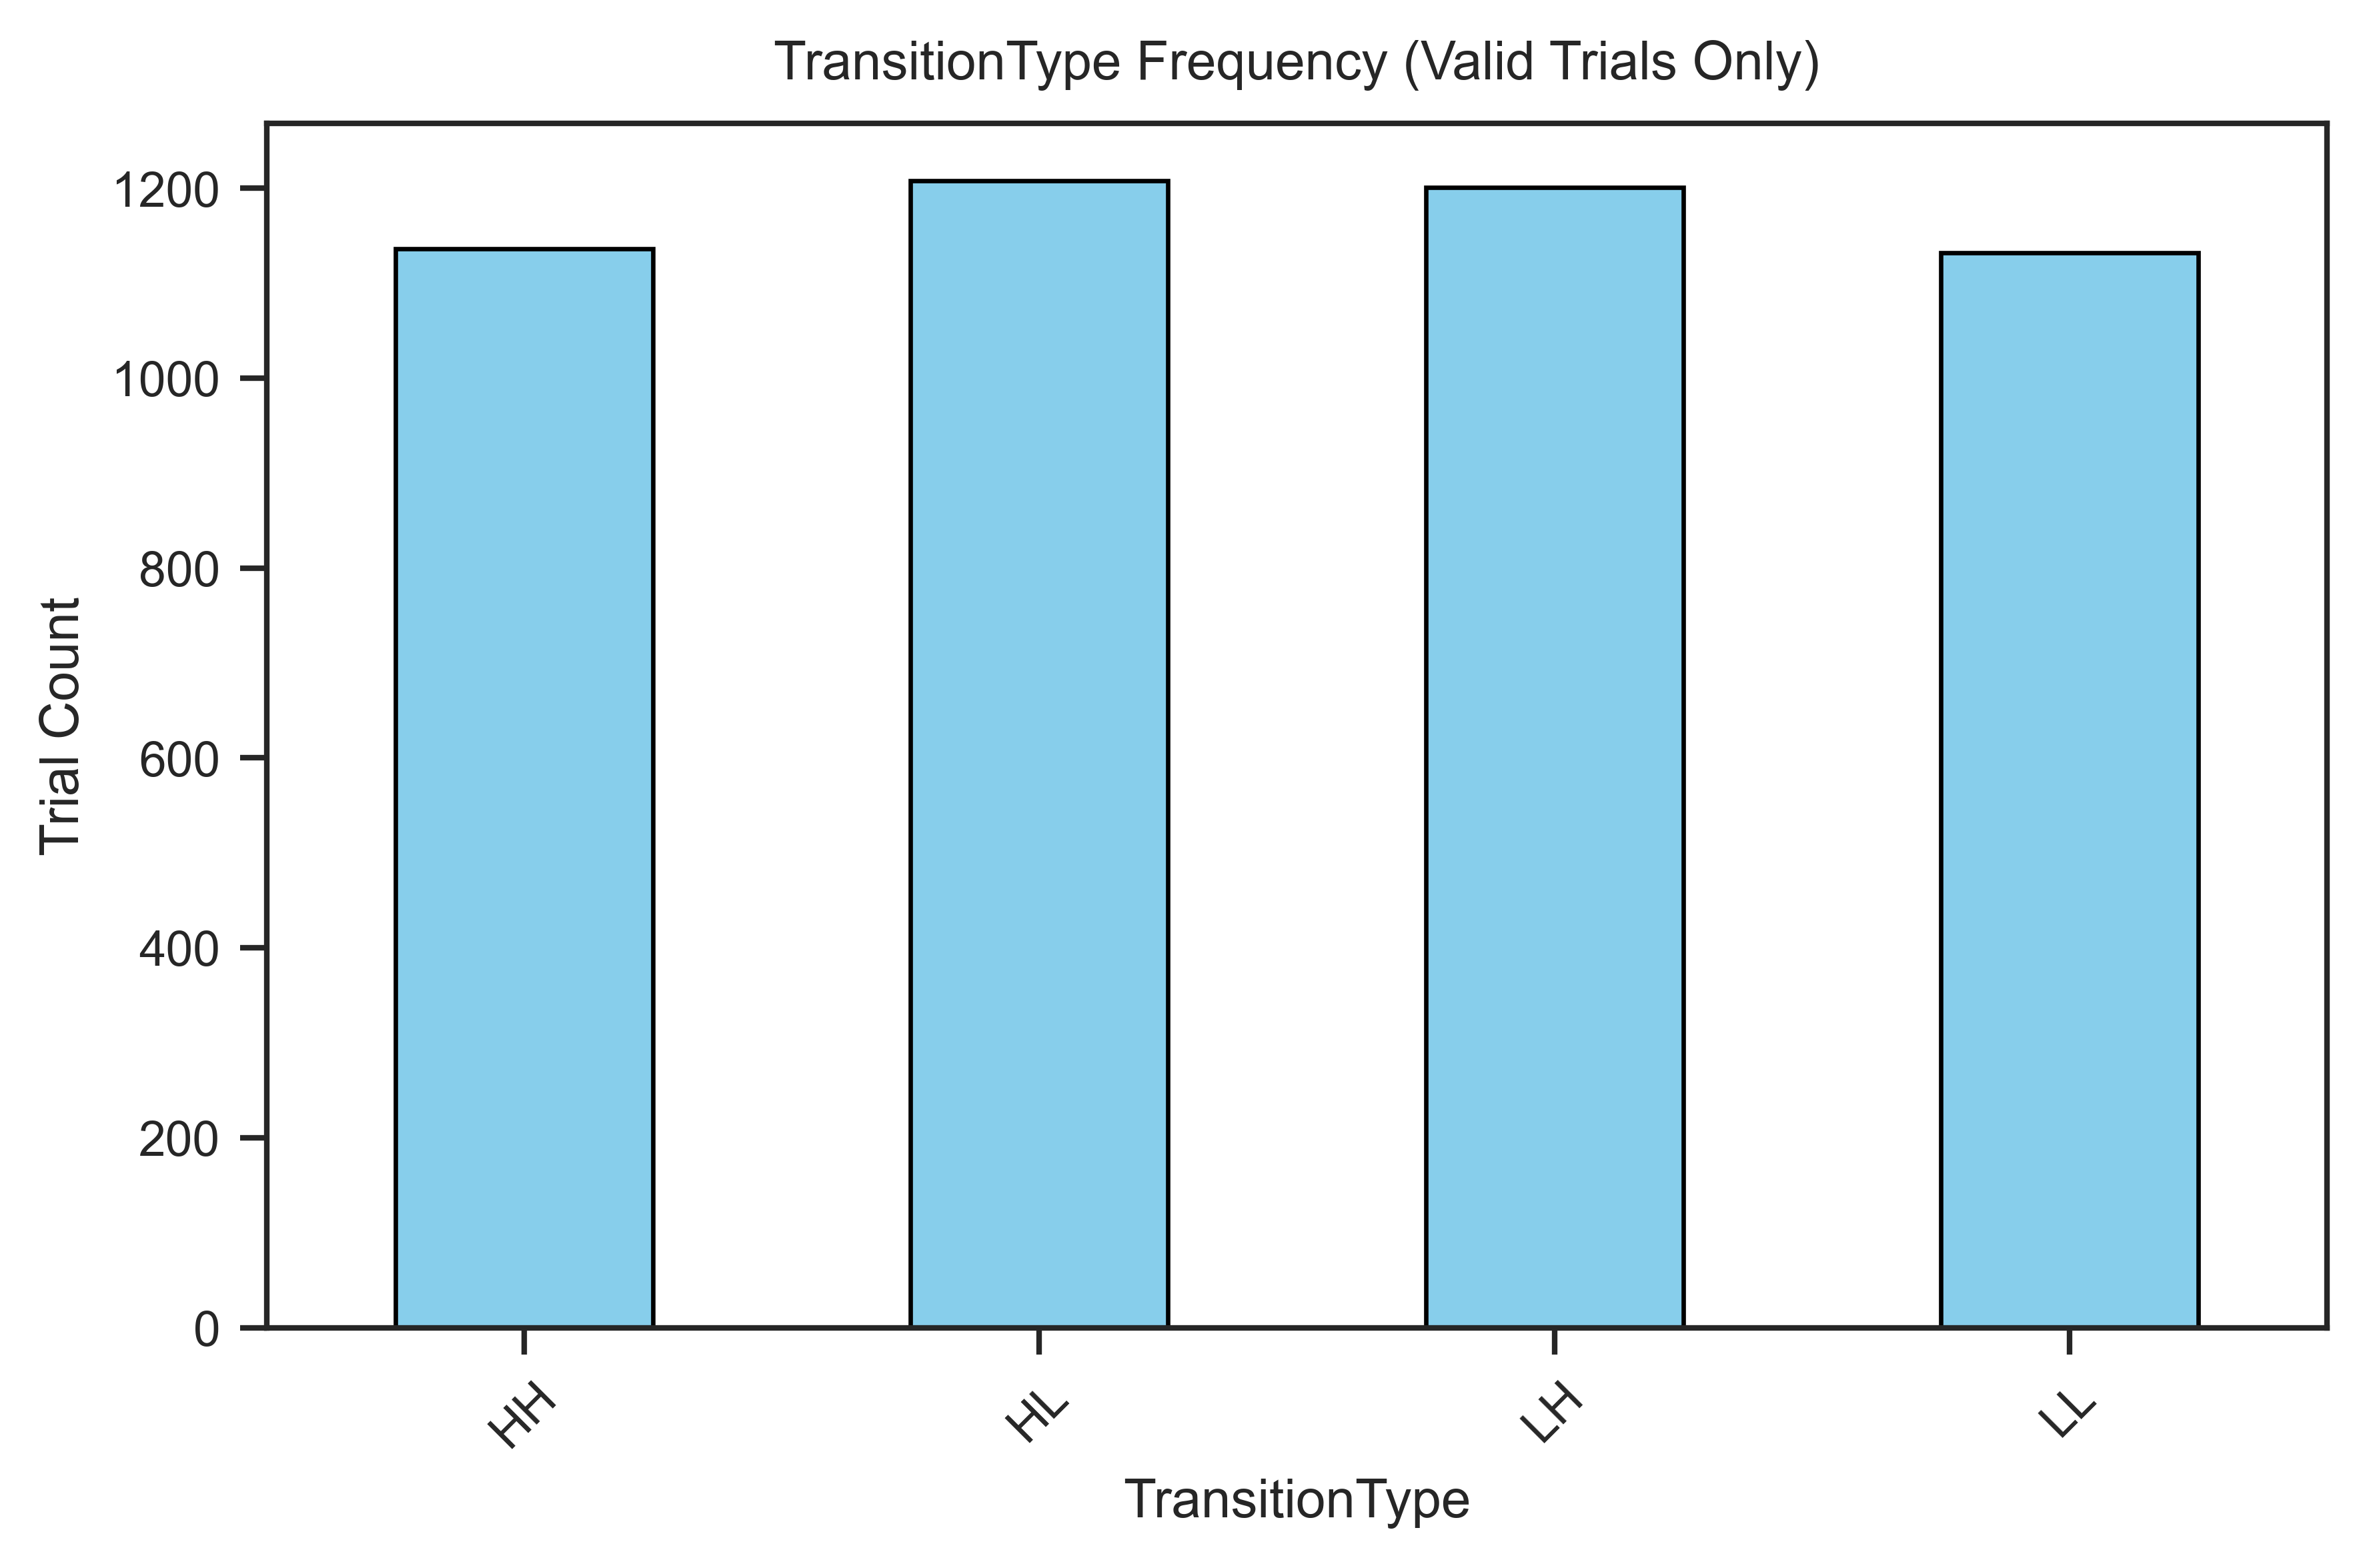

In [14]:
df['preDur1backc'] = df['preDur1back']-1.2
df['curDurc'] = df['curDur']-1.2
df['mean_rpr'] = df.groupby('subID')['rpr'].transform('mean')
df['resp_type'] = np.where(df['rpr'] > df['mean_rpr'], 'Long', 'Short')
df['preResp'] = df.groupby('subID')['resp_type'].shift(1)
dfv = df[df["is_outlier"] == False].copy()
transition_counts = dfv["TransitionType"].value_counts().sort_index()
transition_prop = dfv["TransitionType"].value_counts(normalize=True).sort_index()
transition_counts.plot.bar(color='skyblue', edgecolor='black', figsize=(6, 4))
plt.title("TransitionType Frequency (Valid Trials Only)")
plt.xlabel("TransitionType")
plt.ylabel("Trial Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Check transition type balance per subject

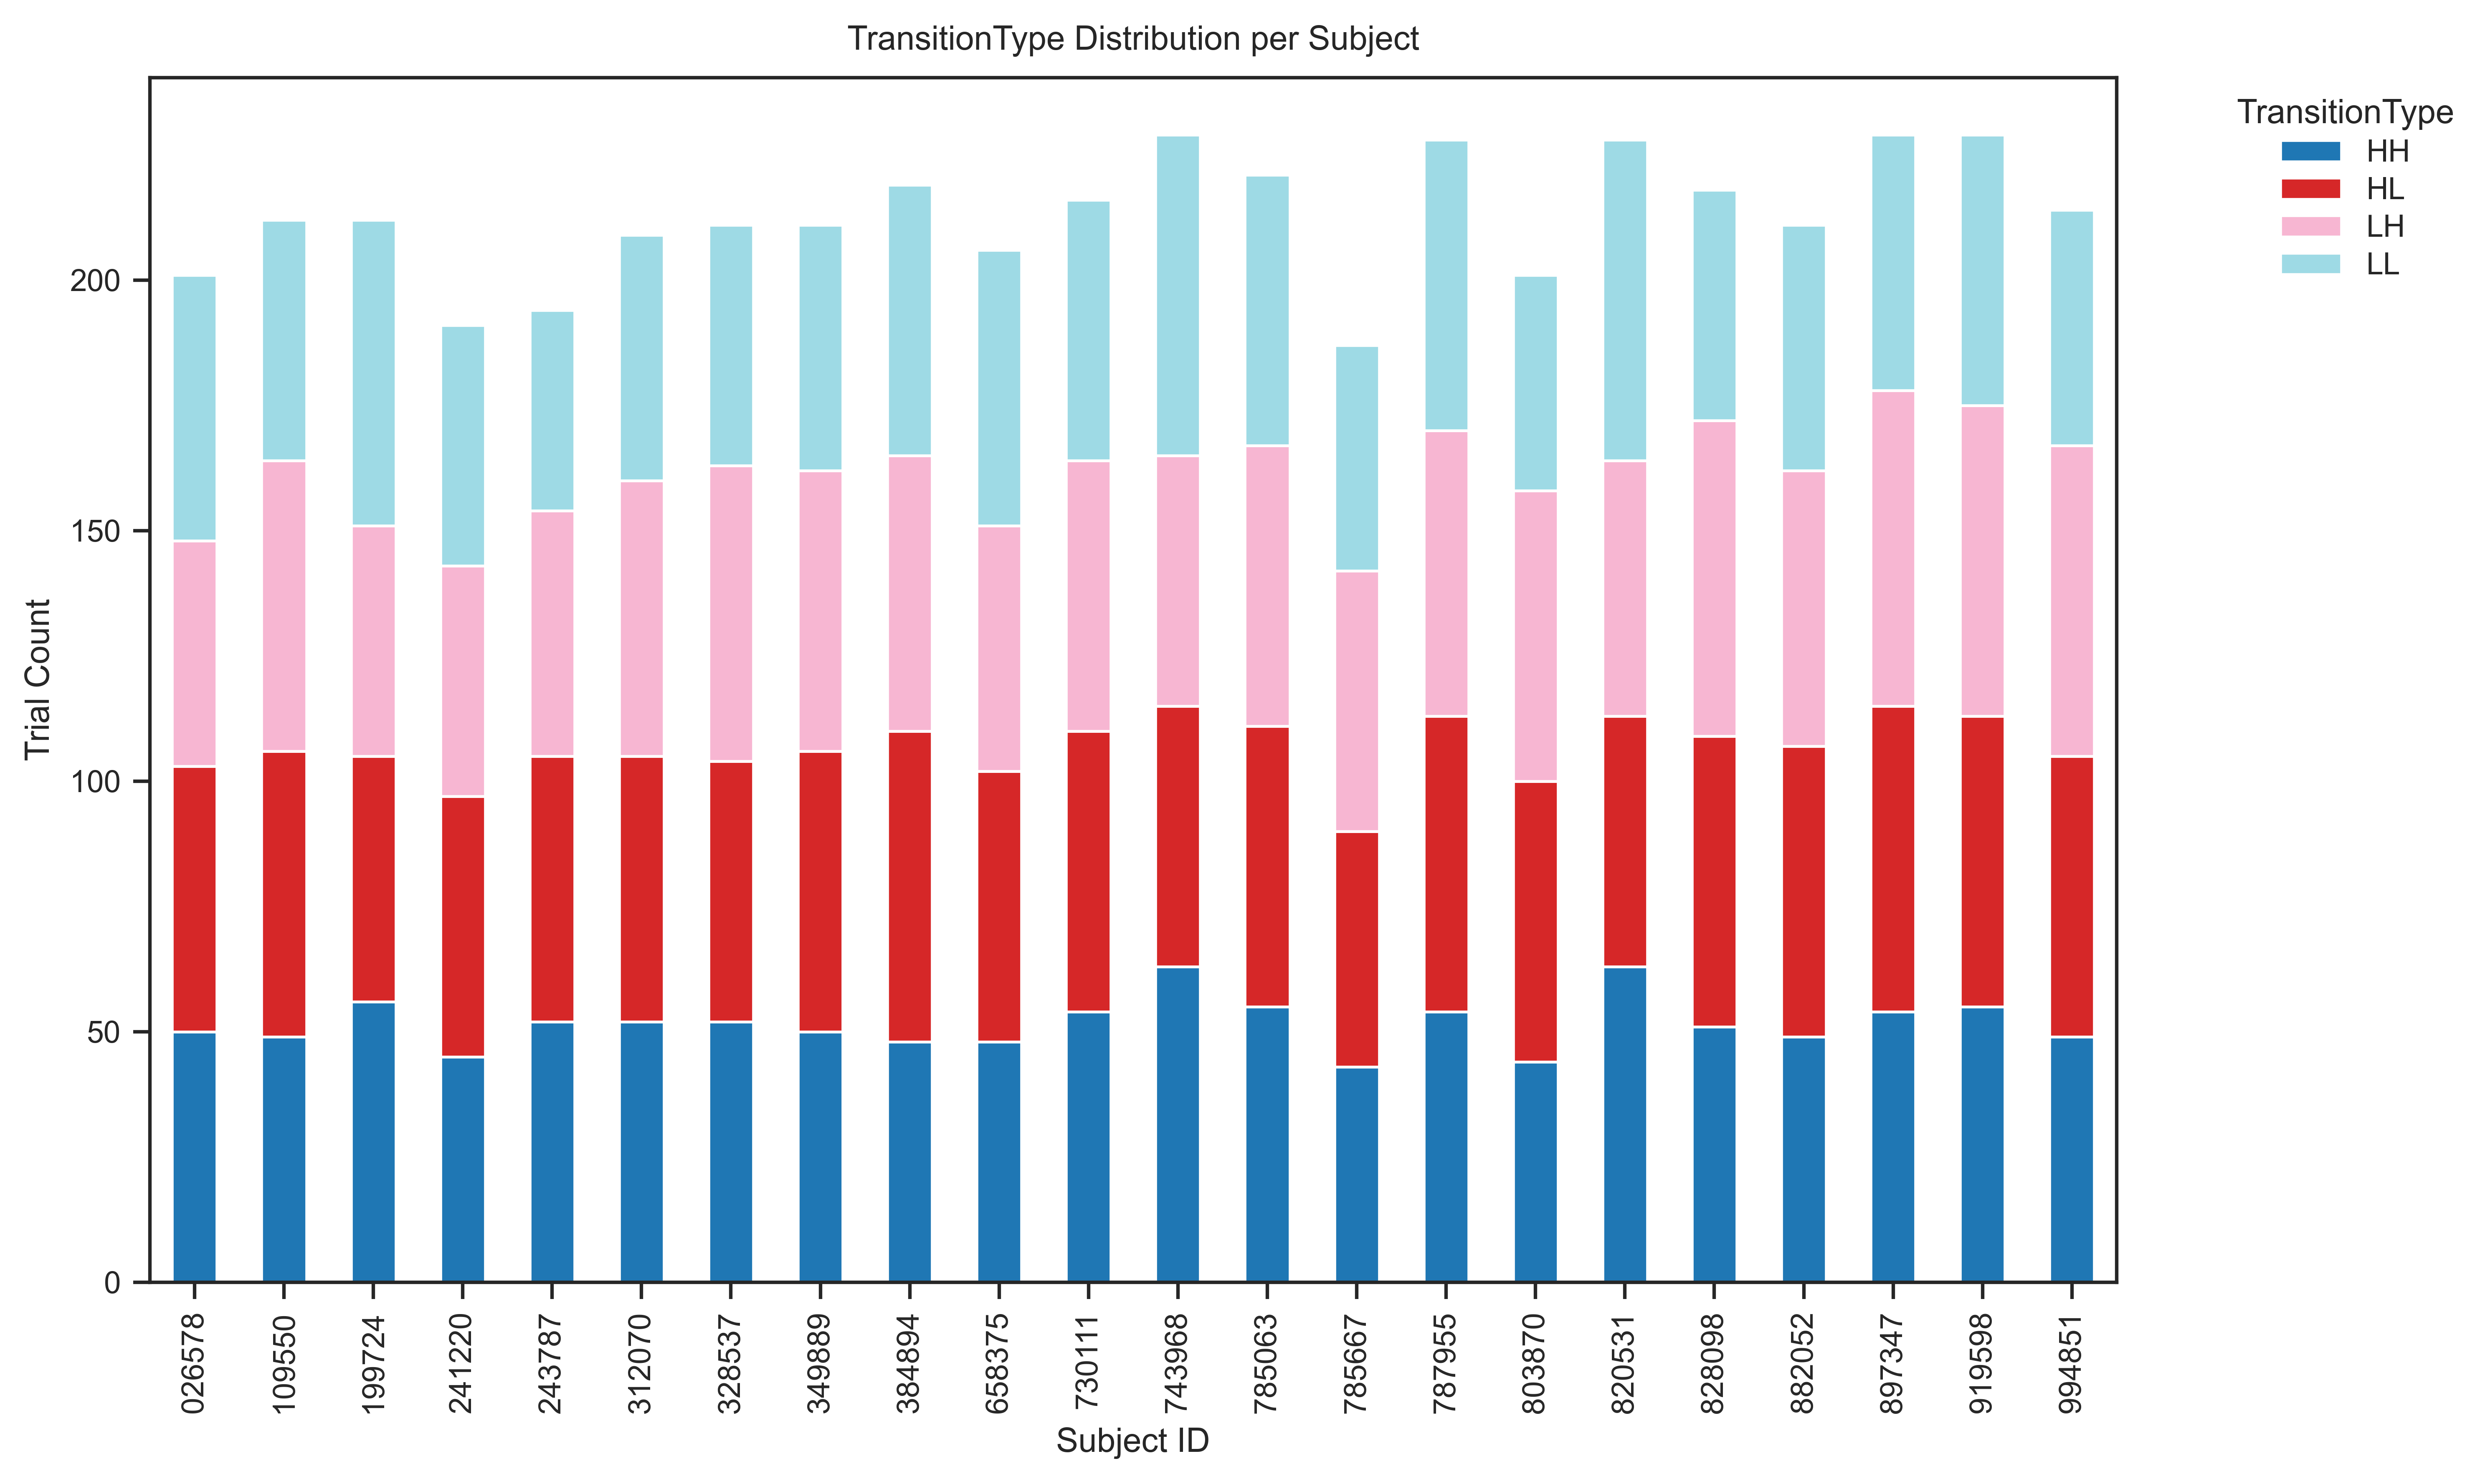

In [15]:
# Trial count per subject × condition
transition_counts = dfv.pivot_table(
    index="subID",
    columns="TransitionType",
    aggfunc="size",
    fill_value=0
)
# Add total trial count per subject
transition_counts["Total"] = transition_counts.sum(axis=1)
# Print trial count table
# Plot stacked bar chart
transition_counts.drop(columns="Total").plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)
plt.title("TransitionType Distribution per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Trial Count")
plt.xticks(rotation=90)
plt.legend(title="TransitionType", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
# Compute and print percentage per condition
transition_props = transition_counts.drop(columns="Total").div(transition_counts["Total"], axis=0)


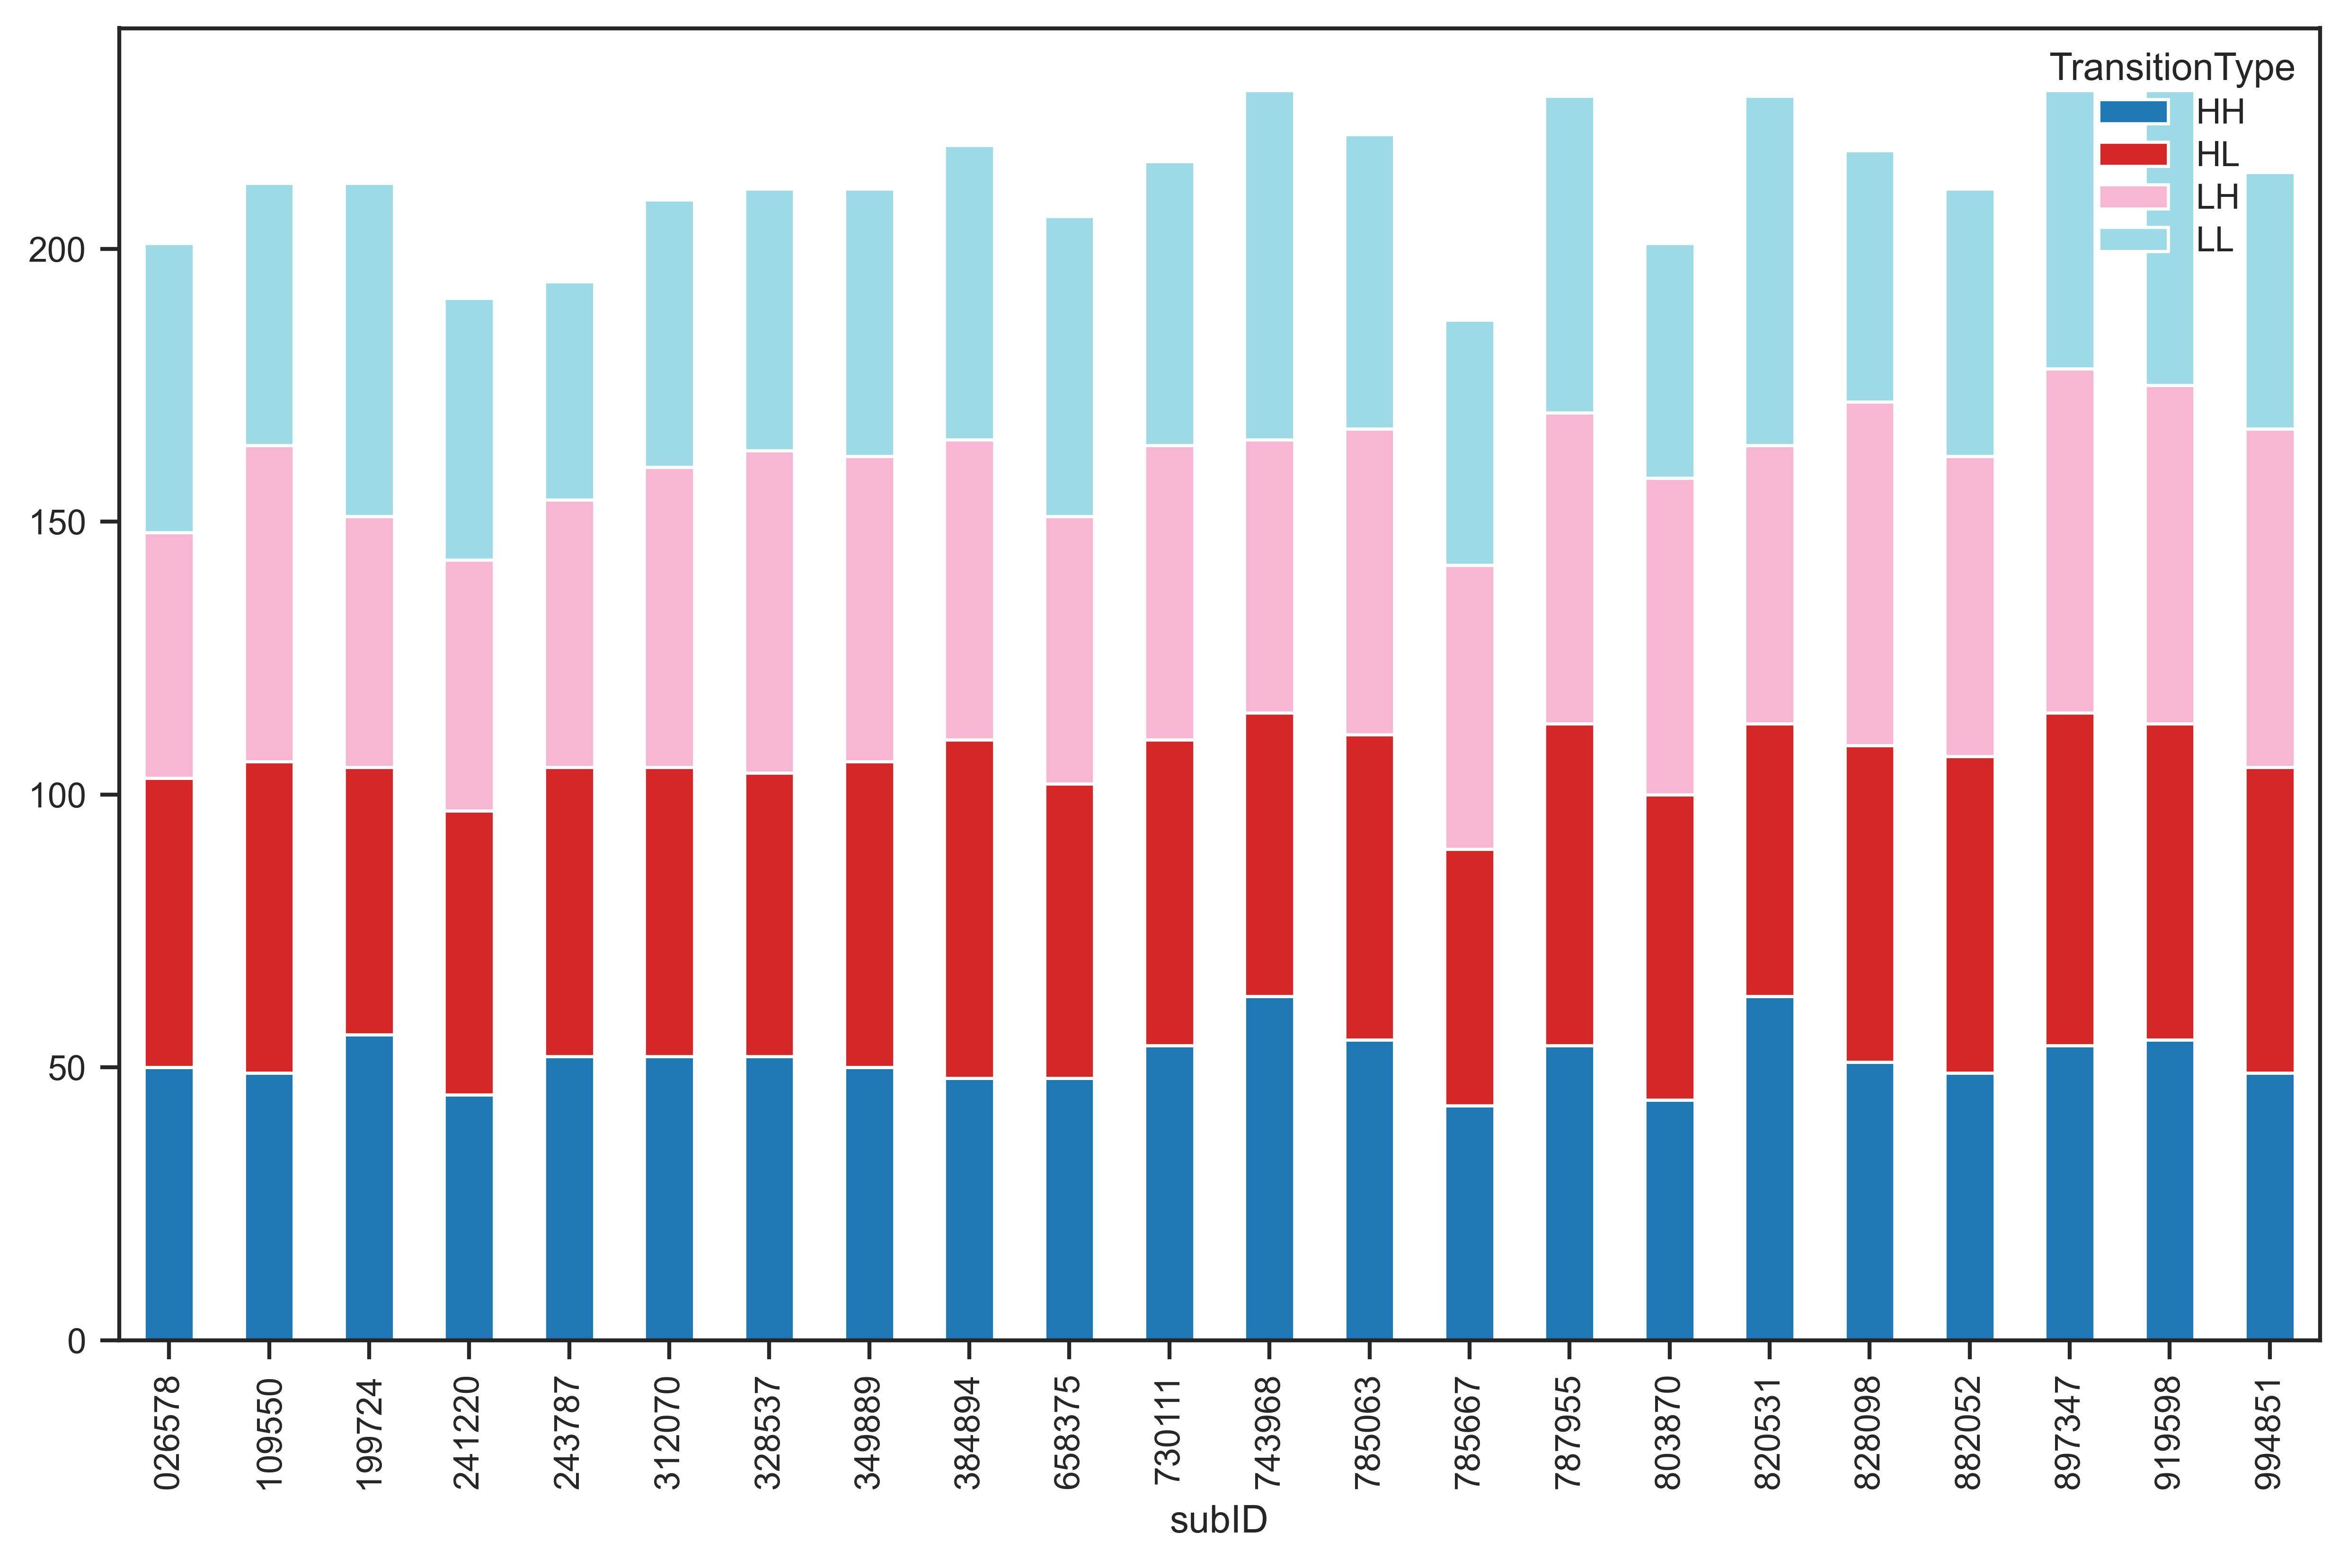

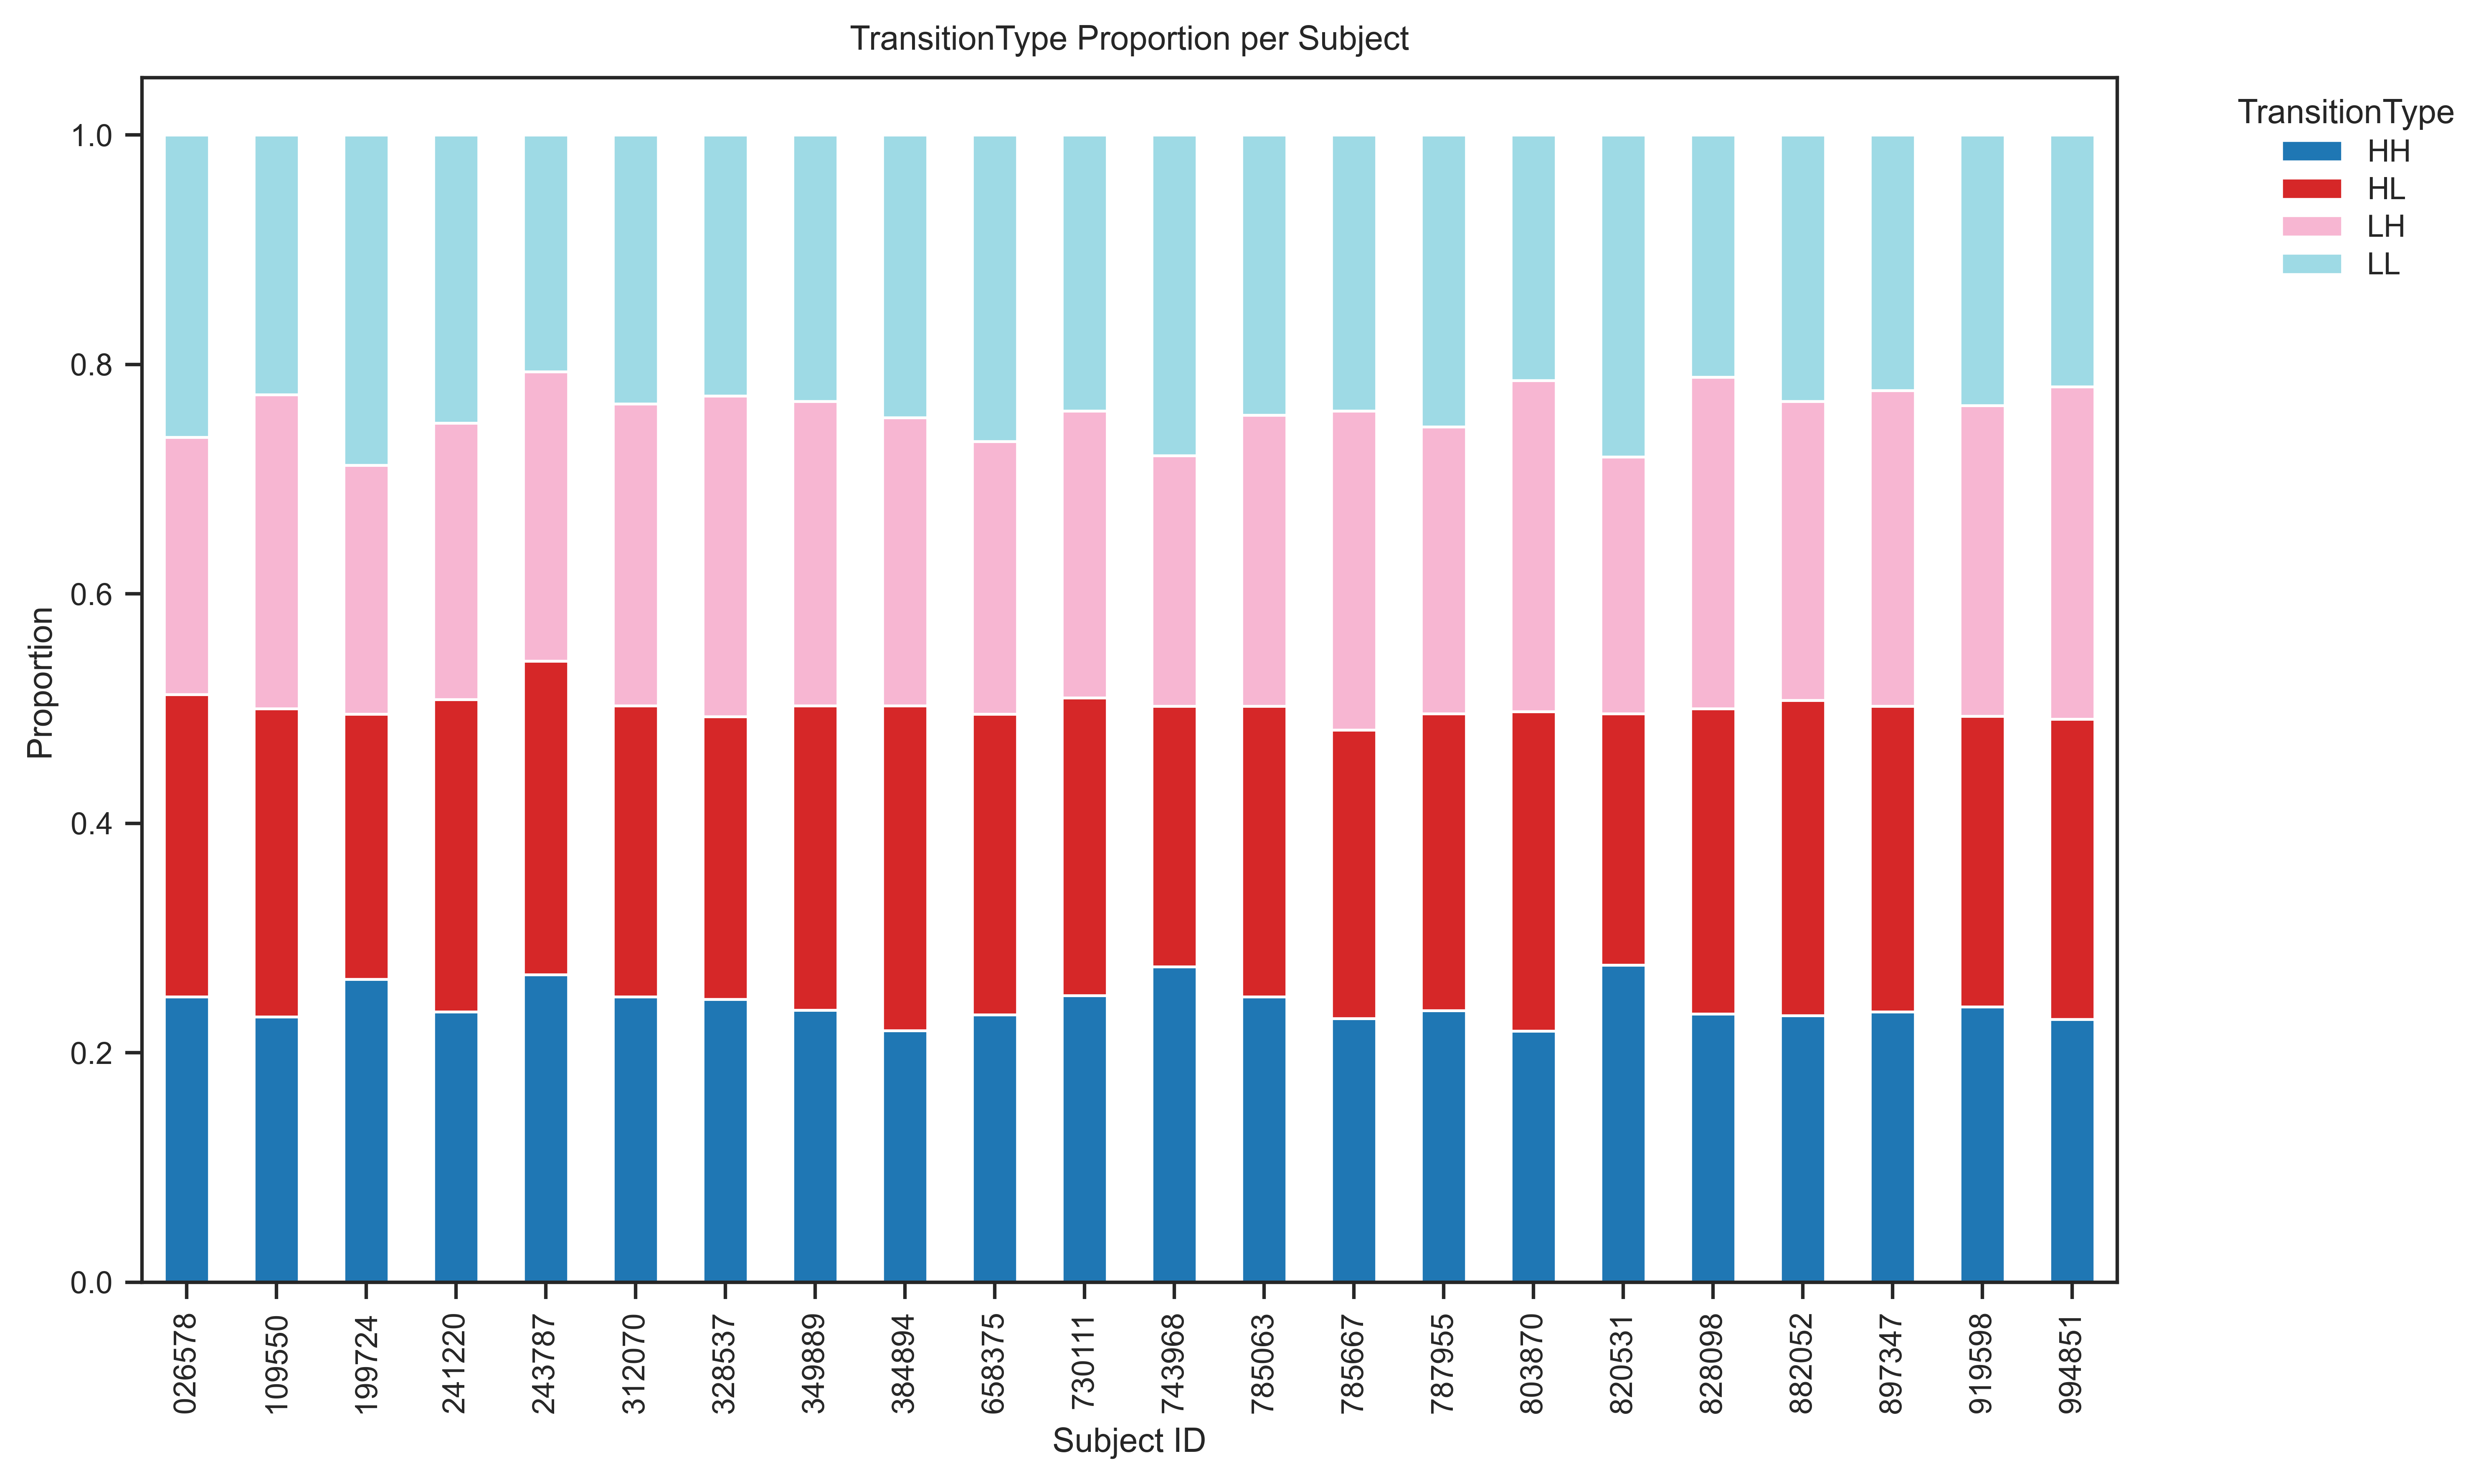

In [16]:
# subID × TransitionType 
transition_by_subject = dfv.pivot_table( index="subID", columns="TransitionType", aggfunc="size", fill_value=0)
transition_by_subject.plot( kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
transition_prop = transition_by_subject.div(transition_by_subject.sum(axis=1), axis=0)
transition_prop.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("TransitionType Proportion per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.legend(title="TransitionType", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Total trials: 5280 -> 4677 (88.6% retained)
Trials per subject: mean=212.6, std=12.4, min=187


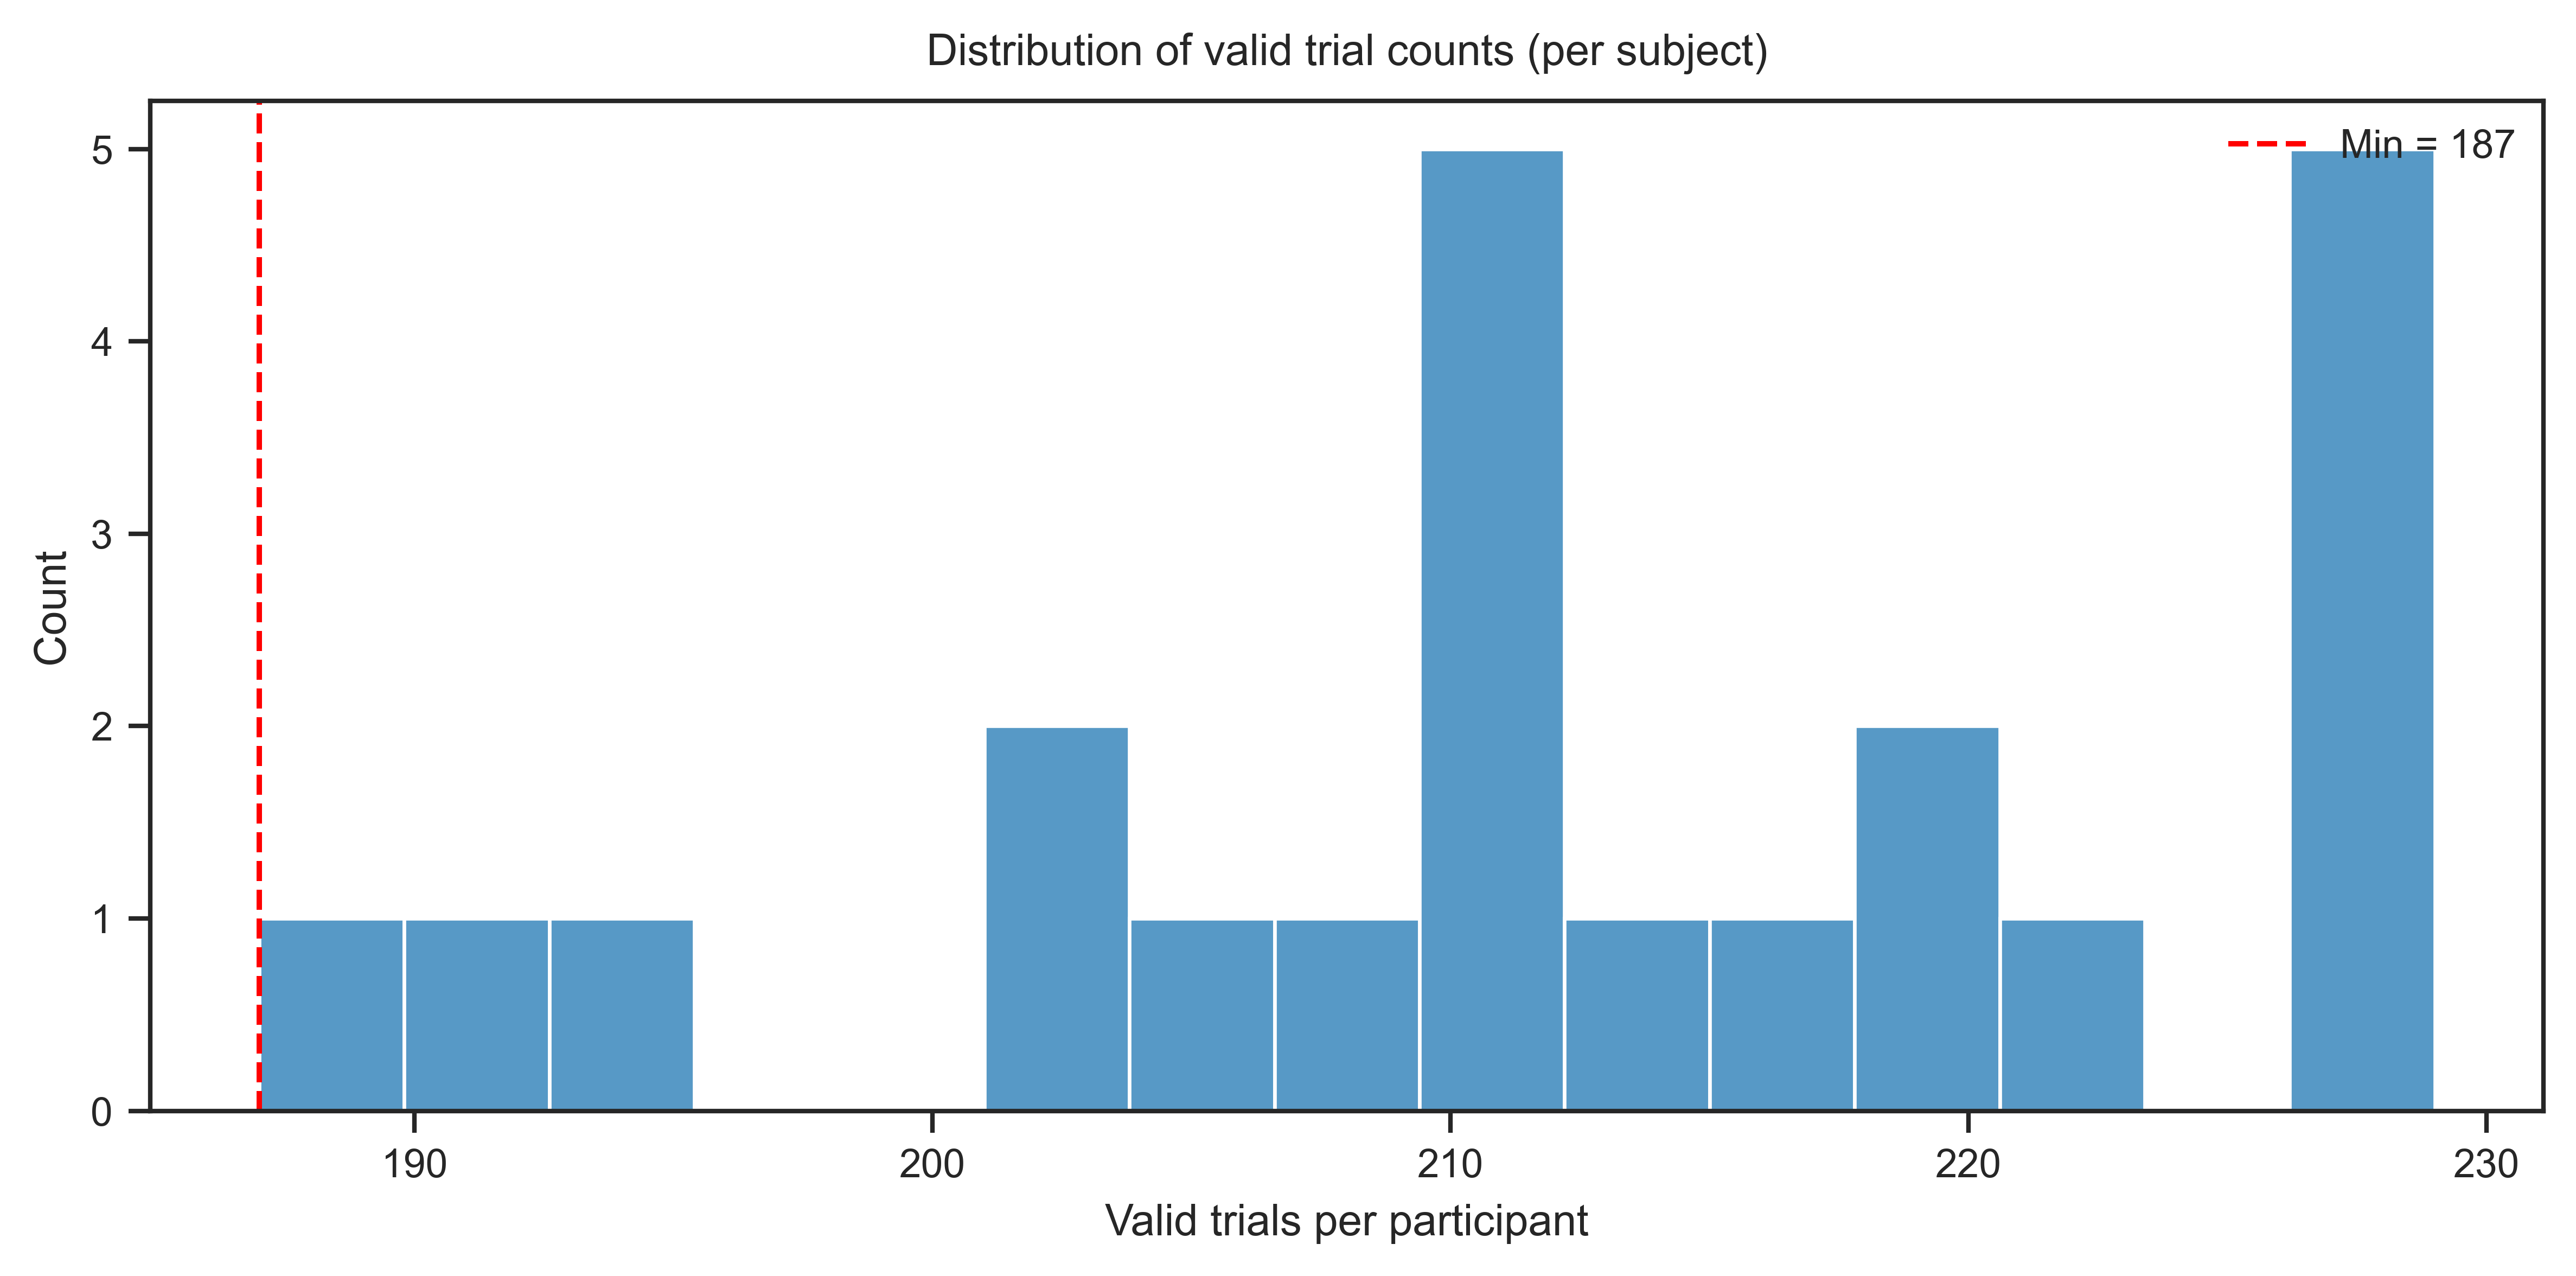

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df[df['is_outlier'] == False]
trials_per_sub = df_clean.groupby('subID').size()
min_trials = trials_per_sub.min()
mean_trials = trials_per_sub.mean()
std_trials = trials_per_sub.std()
total_trials_before = len(df)
total_trials_after = len(df_clean)
retention_rate = total_trials_after / total_trials_before * 100

print(f"Total trials: {total_trials_before} -> {total_trials_after} ({retention_rate:.1f}% retained)")
print(f"Trials per subject: mean={mean_trials:.1f}, std={std_trials:.1f}, min={min_trials}")

low_trial_subjects = trials_per_sub[trials_per_sub < 180]
if not low_trial_subjects.empty:
    print(f"Warning: {len(low_trial_subjects)} subjects have < 180 trials")

plt.figure(figsize=(8, 4))
sns.histplot(trials_per_sub, bins=15, kde=False)
plt.axvline(min_trials, color='r', linestyle='--', label=f'Min = {min_trials}')
plt.xlabel("Valid trials per participant")
plt.ylabel("Count")
plt.title("Distribution of valid trial counts (per subject)")
plt.legend()
plt.tight_layout()
plt.show()

subject_trial_df = trials_per_sub.reset_index()
subject_trial_df.columns = ['subID', 'n_valid_trials']

#### Response variability by coherence level
Compare SD of reproduced durations between high/low coherence conditions.

#### Conclusion
The coherence/uncertainty manipulation is **effective** (t-test significant at each duration level).

In [18]:
# Save a copy to local Analysis folder for compatibility
df.to_pickle("E2.pkl")
print(f"Saved {len(df)} rows, {df['subID'].nunique()} subjects to E2.pkl")

Saved 5280 rows, 22 subjects to E2.pkl
